# Sensitivity analysis — Wnt / RA stemness model

Three complementary methods on the same curated 14-parameter set, evaluated for
**all 8 model outputs** (the 7 state variables **and** the stemness index):

1. **Local sensitivity** — normalized one-at-a-time elasticities around baseline.
2. **Morris** — global screening (`mu*` ranking, `sigma` flags nonlinearity / interactions).
3. **Sobol** — variance-based first-order (`S1`) and total-order (`ST`) indices.

Output metric for every method is the **AUC** (time-average of each trajectory over `tau in [0, 150]`).
Plots use a clean presentation style: no box, plain white background, blue / orange bars.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from SALib.sample.morris import sample as morris_sample
from SALib.analyze.morris import analyze as morris_analyze
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze

# ---- clean presentation style ----
BLUE, ORANGE = "#1f77b4", "#ff7f0e"

def set_clean_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
        "savefig.facecolor": "white",
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.edgecolor":    "#444444",
        "axes.grid":         False,
        "font.size":         11,
        "axes.titlesize":    12,
        "legend.frameon":    False,
    })

set_clean_style()

PLOT_DIR = "sa_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def slug(name):
    return name.lower().replace("-", "").replace(" ", "_")

In [2]:
# ============================================================
# Model (7-variable nondimensional Wnt / RA system) + stemness
# ============================================================
def hill(x, K, n=1):
    x = max(x, 0.0)
    return x ** n / (K ** n + x ** n)

def ra_input(tau, p):
    dietary = p["AR"] * (1.0 + np.cos((2.0 * np.pi * tau / p["TR"]) - p["phi"]))
    treatment = 0.5 * p["DR"] * (
        np.tanh(p["q"] * (tau - p["tau1"])) - np.tanh(p["q"] * (tau - p["tau2"]))
    )
    return p["mu0"] + dietary + treatment

def model(tau, y, p):
    b, apc, h5, h13, m, r, c = np.maximum(y, 0.0)
    deltaP = 1.0 + p["deltaP1"] * (1.0 - p["thetaP"])
    muR = ra_input(tau, p)
    db = (p["W"] + p["eta13"] * hill(h13, p["kappa13"], p["nH"]) - b
          - p["lambdaP"] * apc * b - p["lambda5"] * h5 * b / (p["kappa5"] + b))
    dapc = (1.0 / p["epsP"]) * ((1.0 + p["rho5"] * h5)
            / (1.0 + p["rhoB"] * b + p["rho13"] * h13) - deltaP * apc)
    dh5 = (1.0 / p["eps5"]) * (p["a5"] + p["etaR"] * hill(r, p["kappaR"], 1)
            - h5 - p["etaM"] * m * h5 / (p["kappaM"] + m))
    dh13 = (1.0 / p["eps13"]) * (p["a13"] + p["etaB13"] * hill(b, p["kappaB13"], p["nB"])
            + p["etaM13"] * hill(m, p["kappaM13"], p["nM"]) - h13)
    dm = (1.0 / p["epsM"]) * (p["aM"] + p["etaBM"] * hill(b, p["kappaBM"], p["nB"]) - m)
    dr = (1.0 / p["epsR"]) * (muR - r - p["lambdaC"] * c * r)
    dc = (1.0 / p["epsC"]) * (p["aC"] + p["etaRC"] * hill(r, p["kappaRC"], 1)
            + p["etaBC"] * hill(b, p["kappaBC"], p["nB"]) - c)
    return [db, dapc, dh5, dh13, dm, dr, dc]

BASELINE = {
    "W": 0.80, "thetaP": 1.00, "nB": 2, "nM": 2, "nH": 2,
    "eta13": 0.75, "kappa13": 0.55, "lambdaP": 1.60, "lambda5": 1.30, "kappa5": 0.50,
    "epsP": 1.00, "rho5": 1.10, "rhoB": 1.10, "rho13": 1.30, "deltaP1": 3.50,
    "eps5": 1.20, "a5": 0.15, "etaR": 2.50, "kappaR": 0.40, "etaM": 2.50, "kappaM": 0.50,
    "eps13": 1.00, "a13": 0.18, "etaB13": 0.95, "kappaB13": 0.50, "etaM13": 0.55, "kappaM13": 0.50,
    "epsM": 0.60, "aM": 0.18, "etaBM": 1.35, "kappaBM": 0.50,
    "epsR": 0.40, "lambdaC": 0.85,
    "epsC": 0.80, "aC": 0.08, "etaRC": 1.50, "kappaRC": 0.50, "etaBC": 1.50, "kappaBC": 0.50,
    "mu0": 0.35, "AR": 0.04, "TR": 24.0, "phi": 0.0,
    "DR": 1.50, "q": 0.30, "tau1": 40.0, "tau2": 80.0,
    "alpha13": 1.00, "alpha5": 1.00,
}

# Curated, biologically meaningful knobs (same set used for the approved Sobol plot)
PARAMS = ["thetaP", "DR", "AR", "etaR", "etaM", "eta13", "etaB13",
          "etaBM", "etaBC", "lambdaC", "lambdaP", "lambda5", "rhoB", "rho13"]

OUTPUT_NAMES = ["b-catenin", "APC", "HOXA5", "HOXA13", "MYC", "RA", "CYP26A1", "Stemness"]

Y0 = [0.20, 1.00, 0.80, 0.30, 0.30, 0.60, 0.40]
TAU_SPAN = (0.0, 150.0)

# +/- 30% bounds around baseline (matches the sampling range used previously)
problem = {
    "num_vars": len(PARAMS),
    "names": PARAMS,
    "bounds": [[BASELINE[k] * 0.7, BASELINE[k] * 1.3] for k in PARAMS],
}

def auc_outputs(p, n_eval=600):
    """Solve the ODE system and return the AUC (time-average) of every output."""
    tau = np.linspace(*TAU_SPAN, n_eval)
    try:
        sol = solve_ivp(lambda t, y: model(t, y, p), TAU_SPAN, Y0, t_eval=tau,
                        method="LSODA", rtol=1e-7, atol=1e-9)
        if not sol.success:
            return np.full(len(OUTPUT_NAMES), np.nan)
    except Exception:
        return np.full(len(OUTPUT_NAMES), np.nan)
    b, apc, h5, h13 = sol.y[0], sol.y[1], sol.y[2], sol.y[3]
    S = b * (1.0 + p["alpha13"] * h13) / (1.0 + apc + p["alpha5"] * h5)
    series = list(sol.y) + [S]
    span = TAU_SPAN[1] - TAU_SPAN[0]
    return np.array([np.trapezoid(s, sol.t) / span for s in series])

def evaluate_matrix(X):
    """Run the model for every row of a SALib sample matrix -> Y (n_samples, n_outputs)."""
    n = X.shape[0]
    Y = np.full((n, len(OUTPUT_NAMES)), np.nan)
    for i in range(n):
        if i % 500 == 0:
            print(f"  {i}/{n}")
        p = BASELINE.copy()
        for k, key in enumerate(PARAMS):
            p[key] = X[i, k]
        Y[i] = auc_outputs(p)
    # impute any failed solves with the column mean so SALib gets finite input
    n_fail = np.isnan(Y).any(axis=1).sum()
    if n_fail:
        print(f"  note: {n_fail} failed solves imputed with column mean")
    col_mean = np.nanmean(Y, axis=0)
    nan_mask = np.isnan(Y)
    Y[nan_mask] = np.take(col_mean, np.where(nan_mask)[1])
    return Y

print("baseline AUC outputs:")
for name, val in zip(OUTPUT_NAMES, auc_outputs(BASELINE)):
    print(f"  {name:<10} {val:.4f}")

baseline AUC outputs:
  b-catenin  0.6364
  APC        0.4734
  HOXA5      0.4440
  HOXA13     1.1846
  MYC        0.9959
  RA         0.3361
  CYP26A1    1.5210
  Stemness   0.7660


## 1. Local sensitivity

Normalized elasticity of each output's AUC to a small (±5%) one-at-a-time perturbation
of each parameter around baseline:

$$ S_{ij} = \frac{\partial Y_i}{\partial p_j}\cdot\frac{p_j}{Y_i} $$

Bars are signed: **blue = output increases with the parameter, orange = output decreases**.

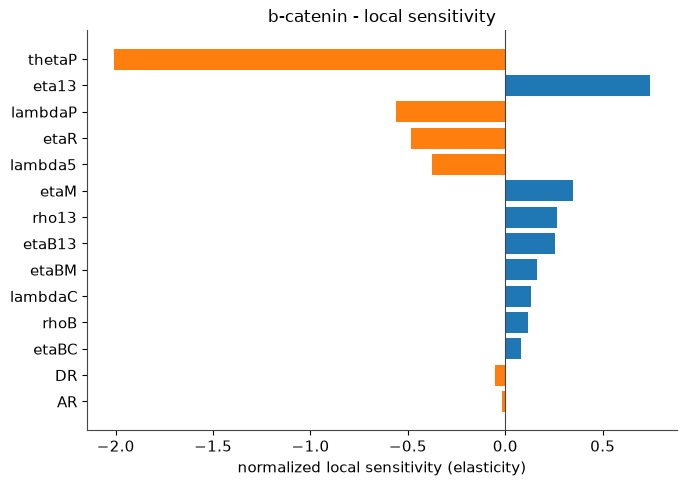

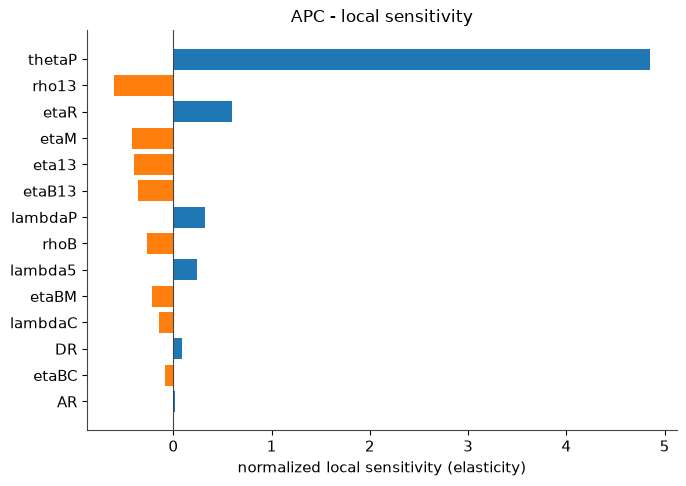

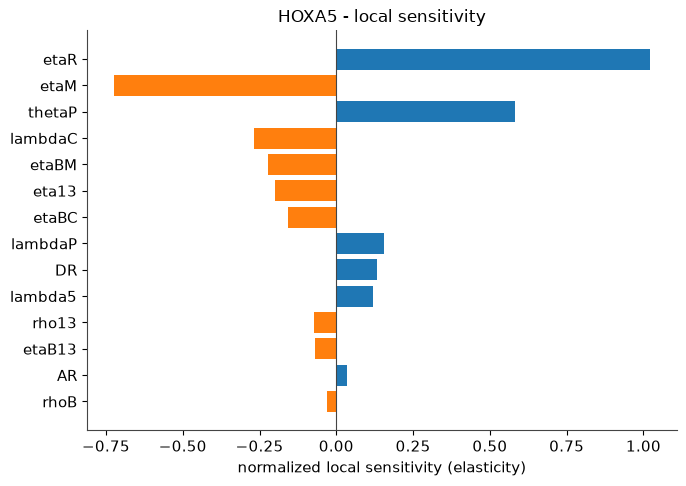

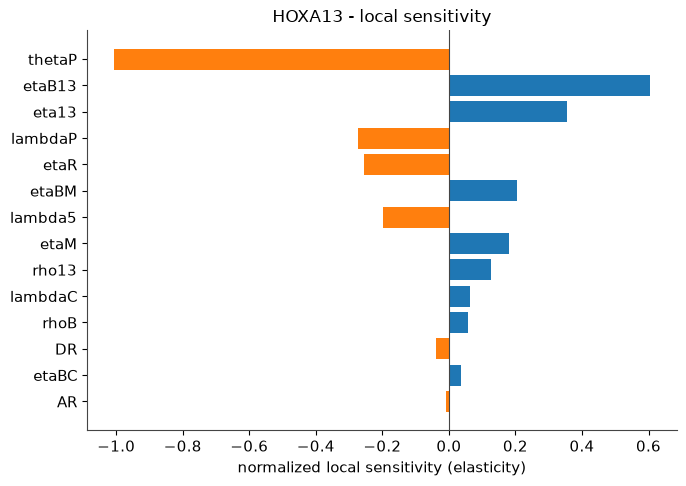

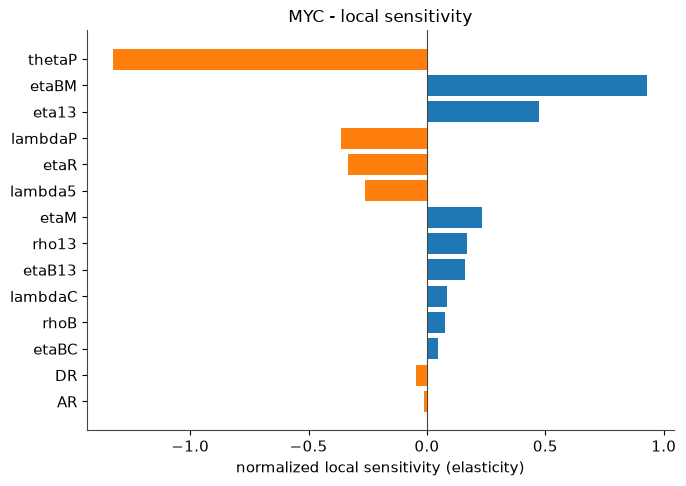

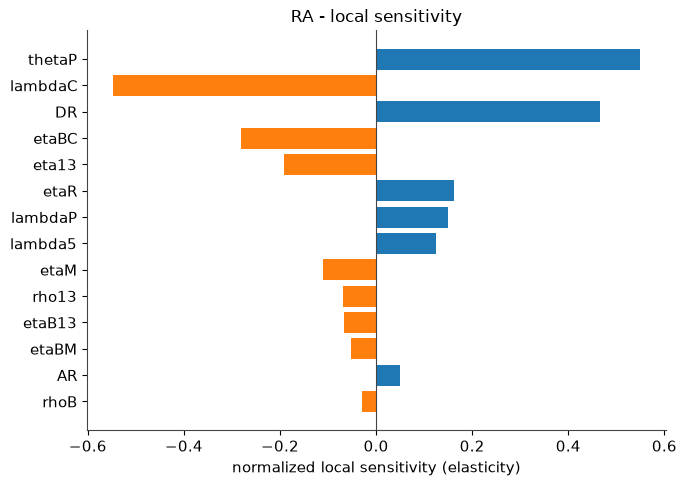

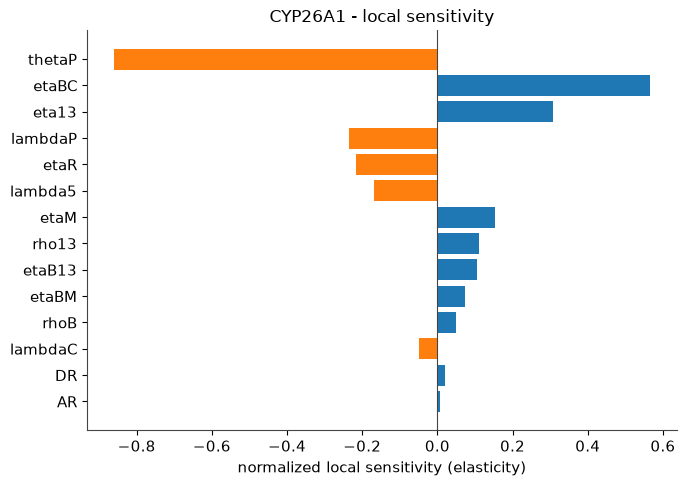

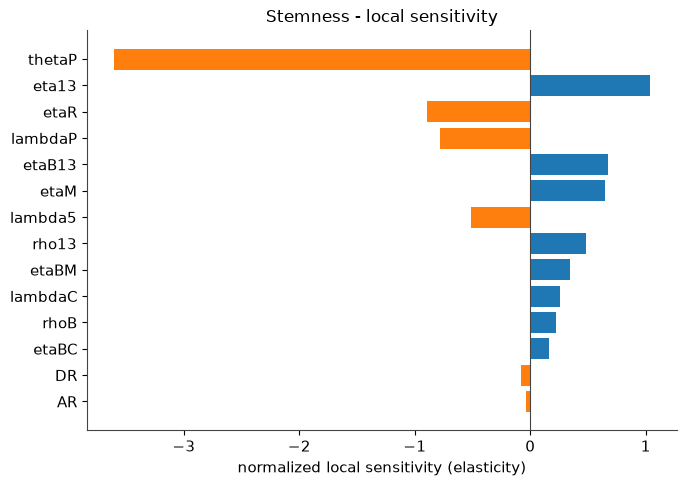

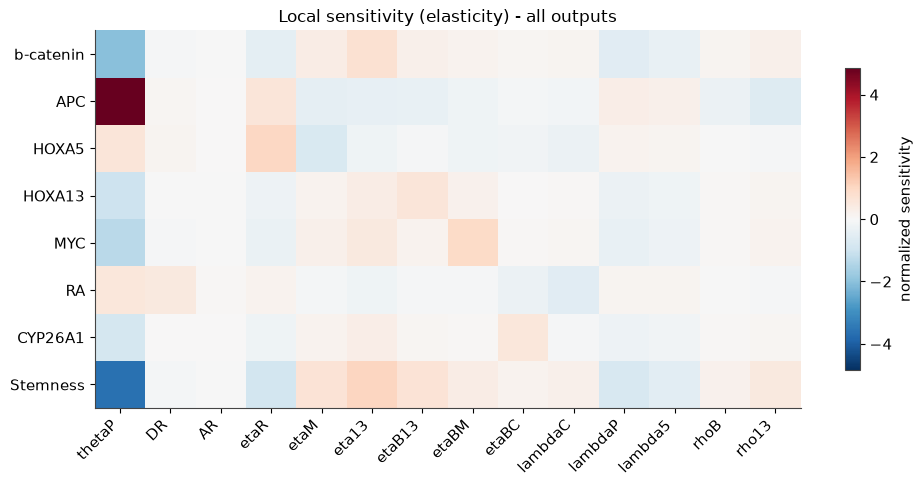

saved local sensitivity plots -> sa_plots


In [3]:
def local_sensitivity(rel_step=0.05):
    base = auc_outputs(BASELINE)
    S = np.zeros((len(OUTPUT_NAMES), len(PARAMS)))
    for j, key in enumerate(PARAMS):
        d = BASELINE[key] * rel_step
        p_hi, p_lo = BASELINE.copy(), BASELINE.copy()
        p_hi[key], p_lo[key] = BASELINE[key] + d, BASELINE[key] - d
        dydp = (auc_outputs(p_hi) - auc_outputs(p_lo)) / (2.0 * d)
        S[:, j] = dydp * BASELINE[key] / base          # normalized elasticity
    return base, S

base, S_local = local_sensitivity()

# one signed bar chart per output (all variables incl. Stemness)
for o, name in enumerate(OUTPUT_NAMES):
    s = S_local[o]
    order = np.argsort(np.abs(s))                       # ascending -> biggest on top
    colors = [BLUE if s[i] >= 0 else ORANGE for i in order]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh([PARAMS[i] for i in order], s[order], color=colors)
    ax.axvline(0, color="#444444", lw=0.8)
    ax.set_xlabel("normalized local sensitivity (elasticity)")
    ax.set_title(f"{name} - local sensitivity")
    fig.tight_layout()
    fig.savefig(f"{PLOT_DIR}/local_{slug(name)}.png", dpi=150)
    plt.show()
    plt.close(fig)

# combined heatmap (outputs x parameters)
fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.abs(S_local).max()
im = ax.imshow(S_local, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(PARAMS))); ax.set_xticklabels(PARAMS, rotation=45, ha="right")
ax.set_yticks(range(len(OUTPUT_NAMES))); ax.set_yticklabels(OUTPUT_NAMES)
ax.set_title("Local sensitivity (elasticity) - all outputs")
fig.colorbar(im, ax=ax, shrink=0.8, label="normalized sensitivity")
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/local_heatmap_all.png", dpi=150)
plt.show()
plt.close(fig)
print("saved local sensitivity plots ->", PLOT_DIR)

## 2. Morris screening

Global elementary-effects screening. **`mu*`** ranks overall influence; **`sigma`**
flags nonlinearity / interactions. Bars are **orange when `sigma > mu*/2`**
(nonlinear / interacting) and **blue otherwise** (near-linear).

Morris: 600 solves...
  0/600
  500/600


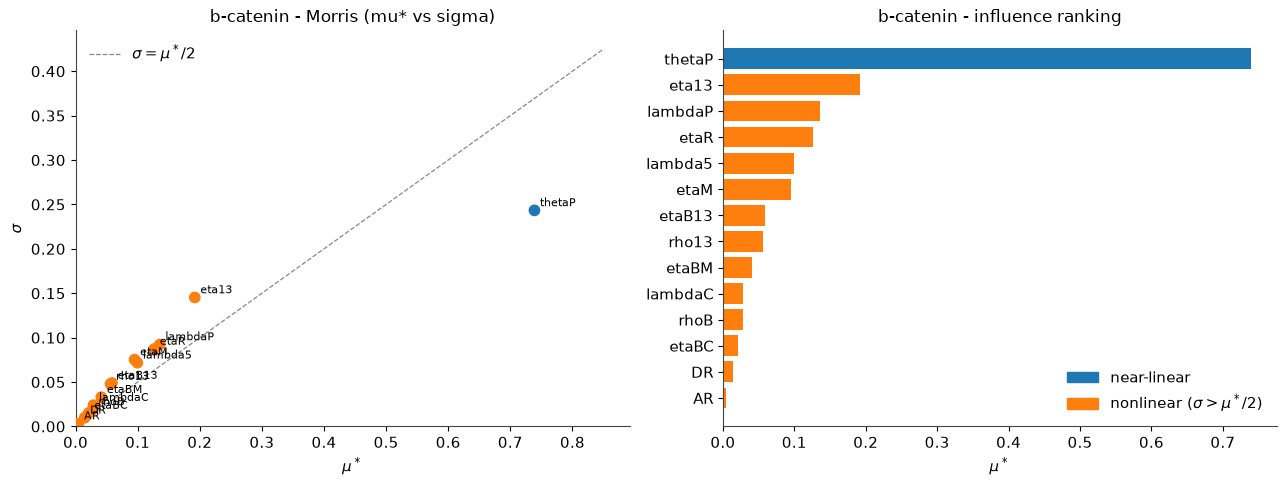

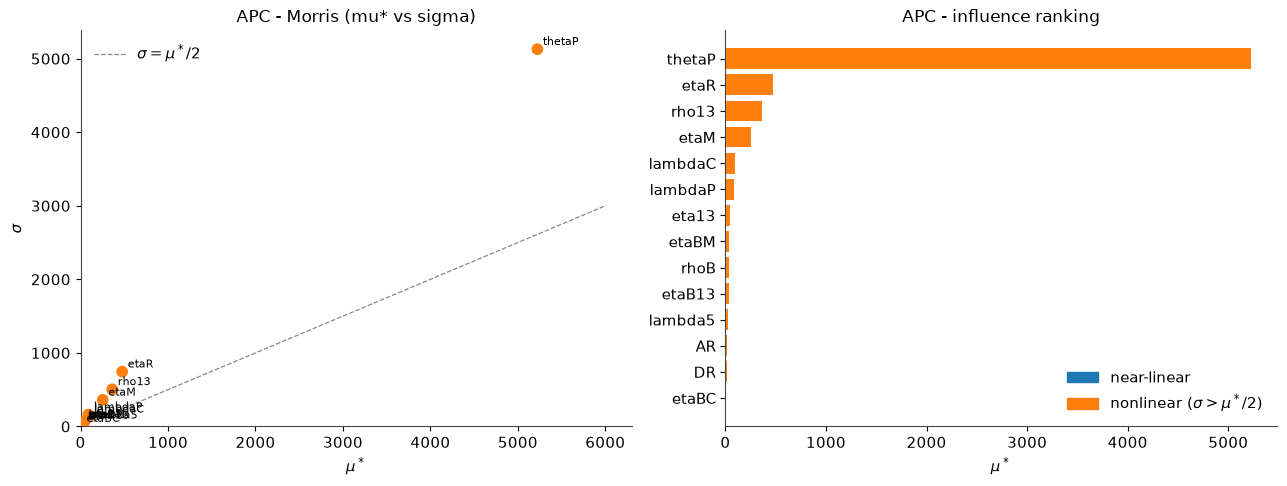

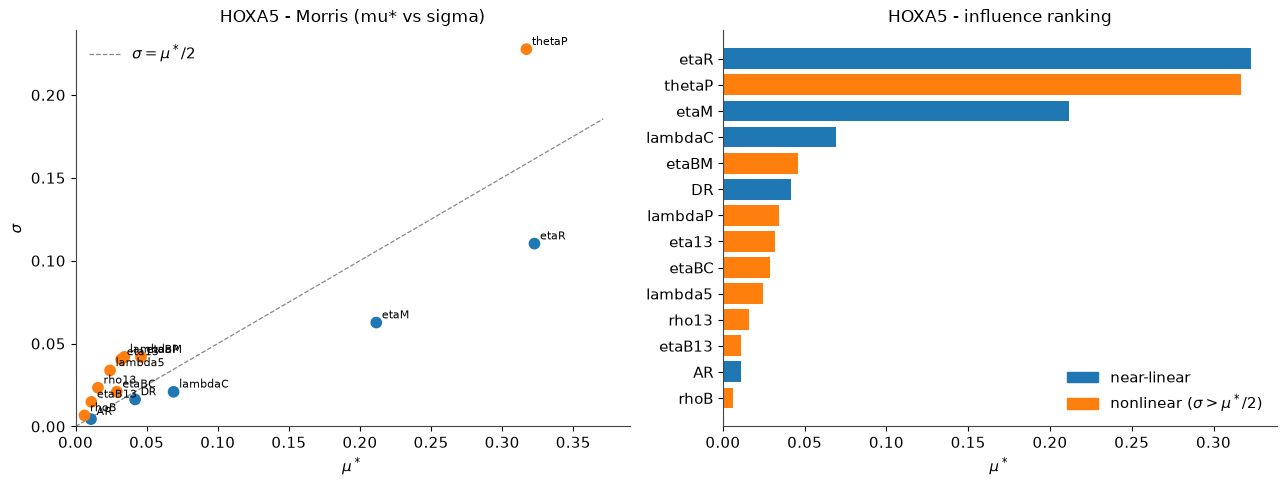

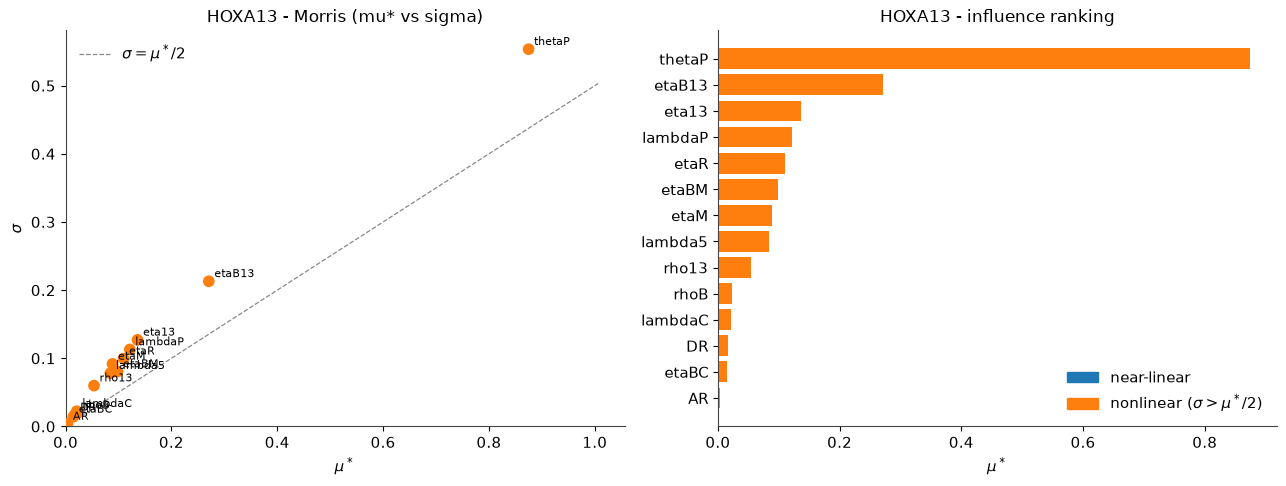

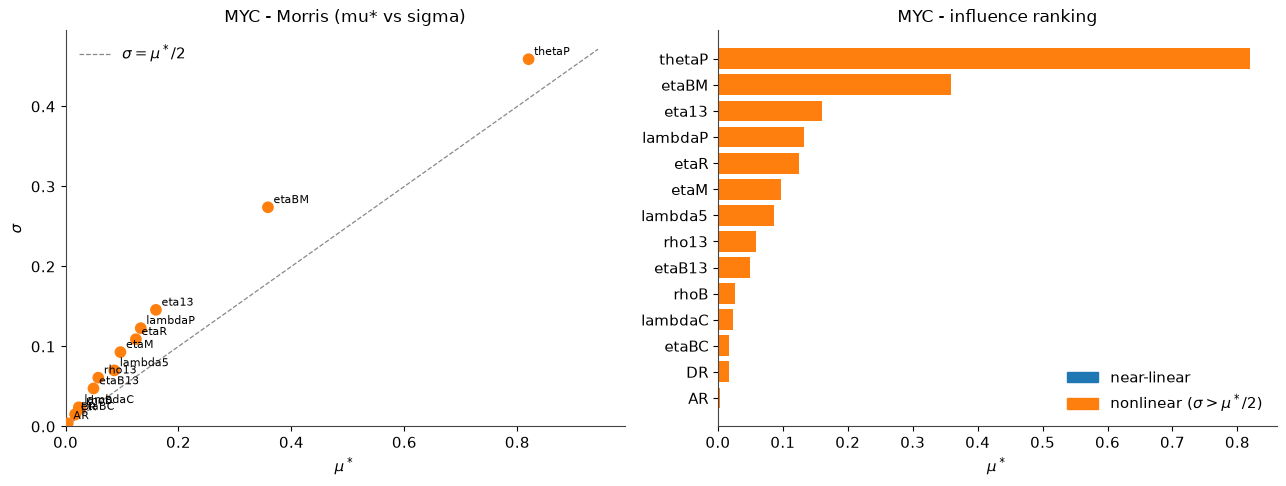

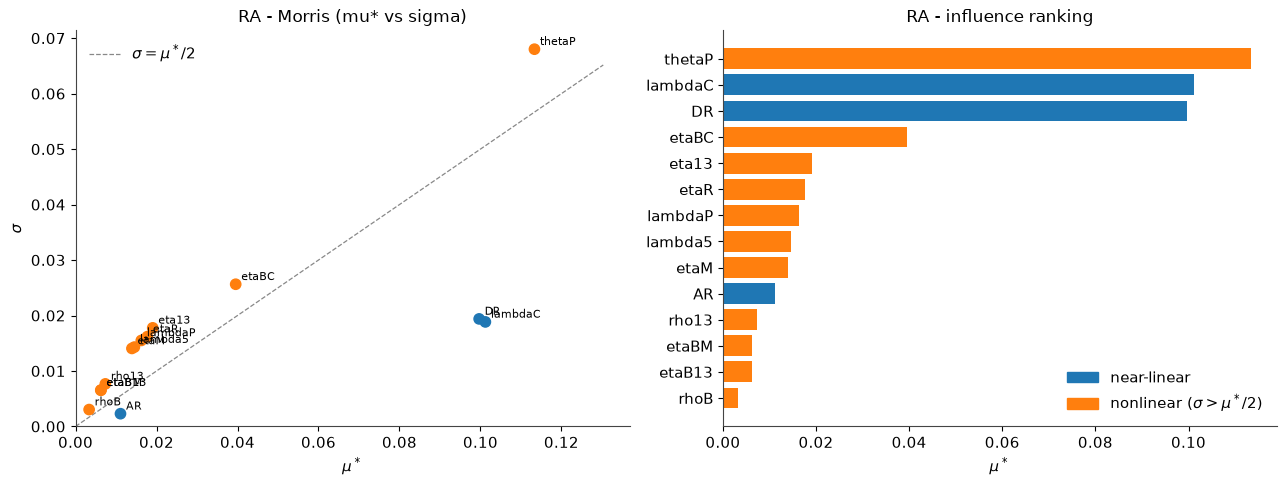

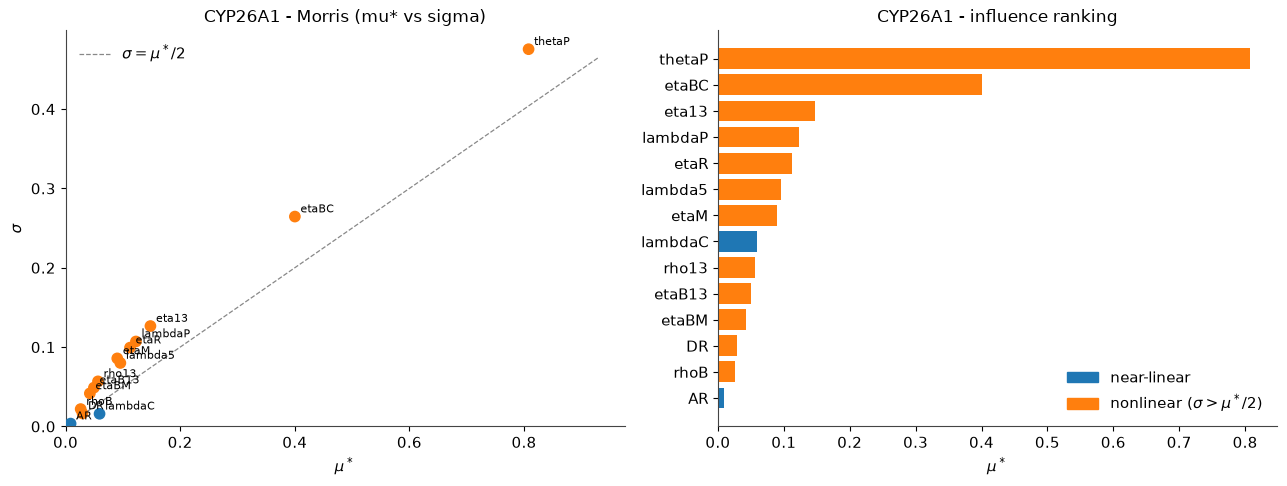

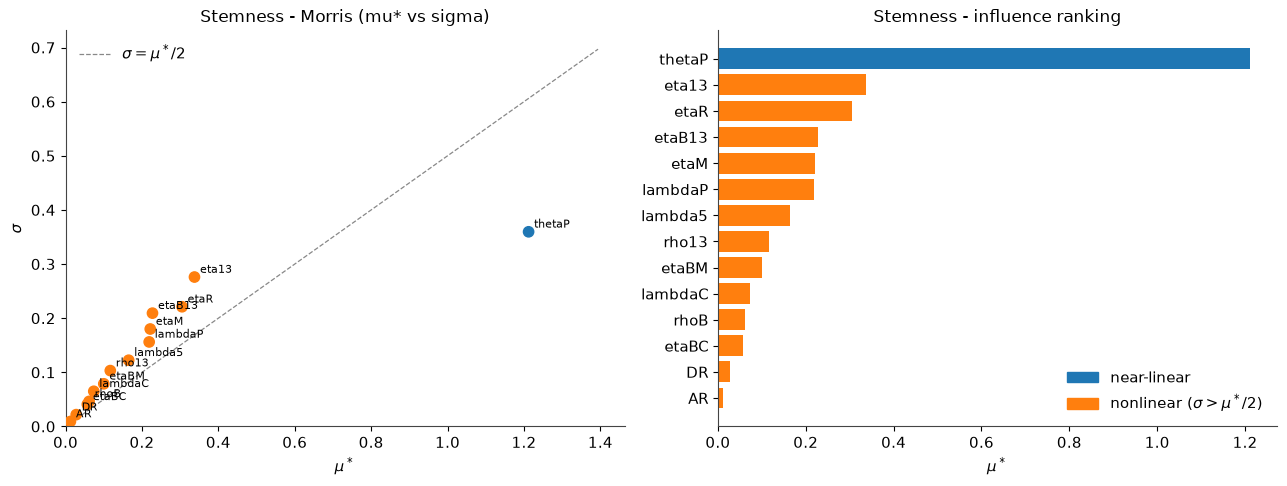

saved Morris plots -> sa_plots


In [4]:
N_MORRIS = 40          # trajectories; total solves = N_MORRIS * (num_vars + 1)
X_m = morris_sample(problem, N_MORRIS, num_levels=4, seed=42)
print(f"Morris: {X_m.shape[0]} solves...")
Y_m = evaluate_matrix(X_m)

for o, name in enumerate(OUTPUT_NAMES):
    Si = morris_analyze(problem, X_m, Y_m[:, o], num_levels=4, seed=42,
                        print_to_console=False)
    mu_star, sigma = Si["mu_star"], Si["sigma"]
    order = np.argsort(mu_star)                          # ascending for barh
    nonlinear = sigma > mu_star / 2.0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # mu* vs sigma scatter
    ax1.scatter(mu_star, sigma, s=55,
                color=[ORANGE if n else BLUE for n in nonlinear], zorder=3)
    for i in range(len(PARAMS)):
        ax1.annotate(PARAMS[i], (mu_star[i], sigma[i]),
                     textcoords="offset points", xytext=(4, 3), fontsize=8)
    lim = max(mu_star.max(), sigma.max()) * 1.15 + 1e-9
    ax1.plot([0, lim], [0, lim / 2], "--", color="#888888", lw=0.9,
             label=r"$\sigma = \mu^*/2$")
    ax1.set_xlim(left=0); ax1.set_ylim(bottom=0)
    ax1.set_xlabel(r"$\mu^*$"); ax1.set_ylabel(r"$\sigma$")
    ax1.set_title(f"{name} - Morris (mu* vs sigma)")
    ax1.legend()

    # mu* ranking bar
    ax2.barh([PARAMS[i] for i in order], mu_star[order],
             color=[ORANGE if nonlinear[i] else BLUE for i in order])
    ax2.set_xlabel(r"$\mu^*$")
    ax2.set_title(f"{name} - influence ranking")
    from matplotlib.patches import Patch
    ax2.legend(handles=[Patch(color=BLUE, label="near-linear"),
                        Patch(color=ORANGE, label=r"nonlinear ($\sigma>\mu^*/2$)")],
               loc="lower right")

    fig.tight_layout()
    fig.savefig(f"{PLOT_DIR}/morris_{slug(name)}.png", dpi=150)
    plt.show()
    plt.close(fig)
print("saved Morris plots ->", PLOT_DIR)

## 3. Sobol indices

Variance-based decomposition. **`S1` (blue) = first-order** (the parameter acting alone),
**`ST` (orange) = total-order** (including all interactions). A gap `ST > S1` indicates
the parameter acts through interactions.

Sobol: 4096 solves...
  0/4096
  500/4096
  1000/4096
  1500/4096
  2000/4096
  2500/4096
  3000/4096
  3500/4096
  4000/4096


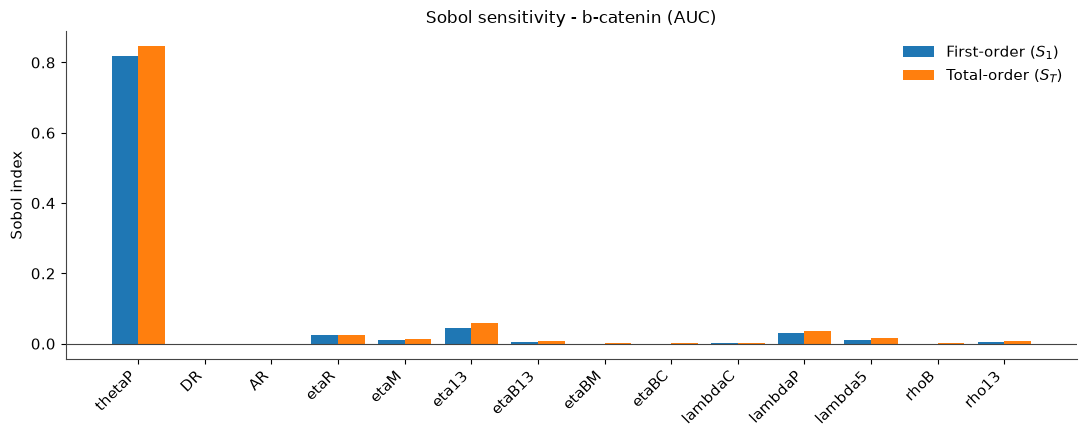

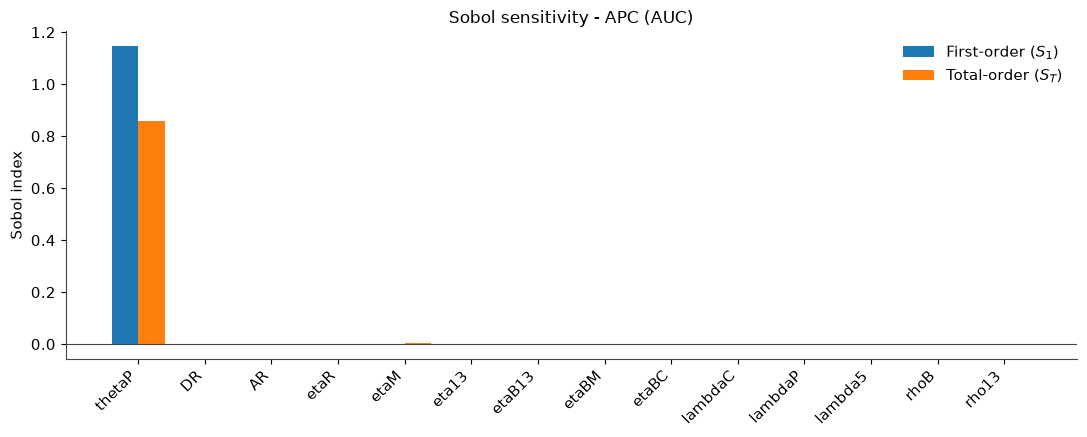

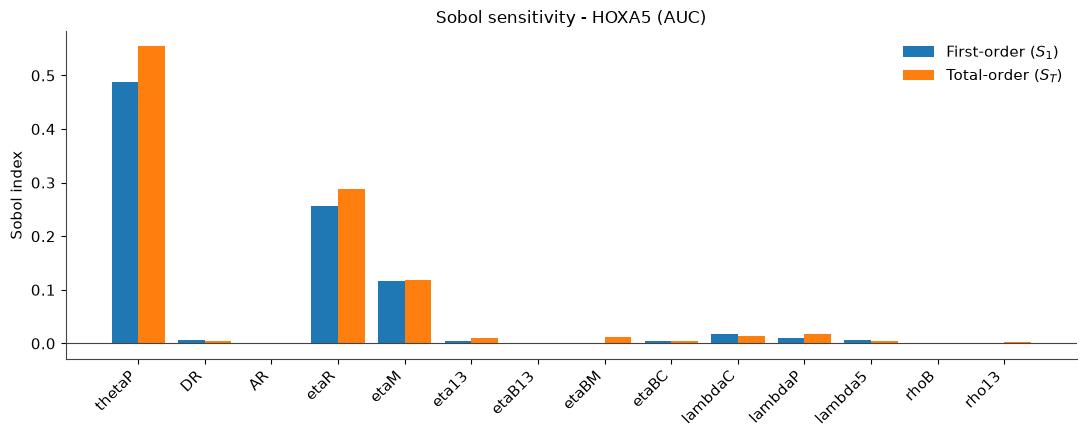

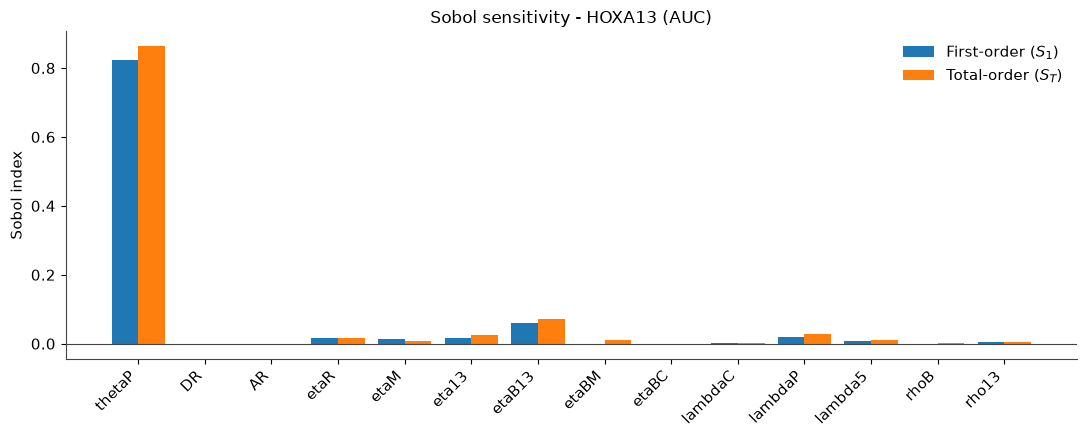

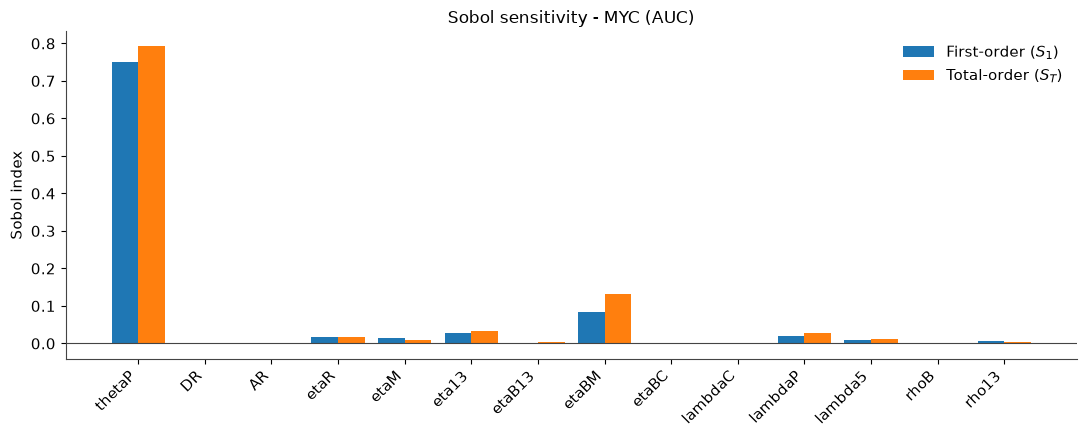

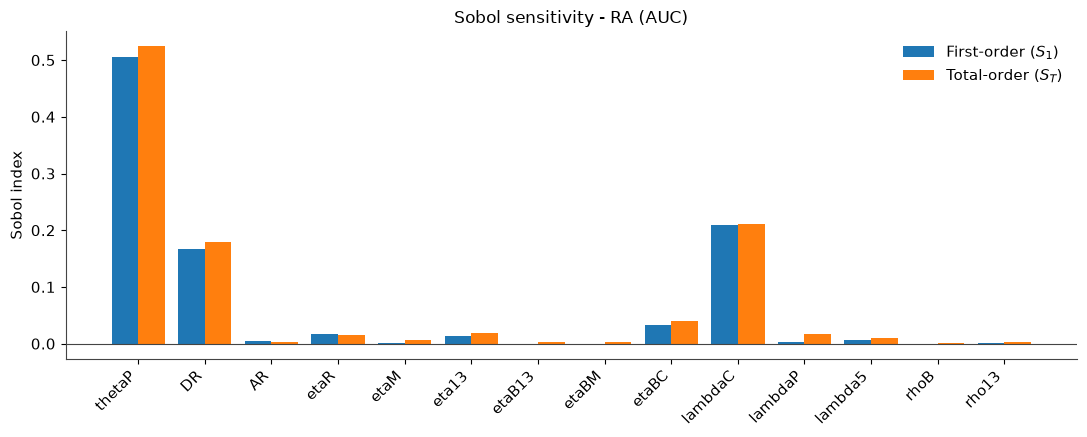

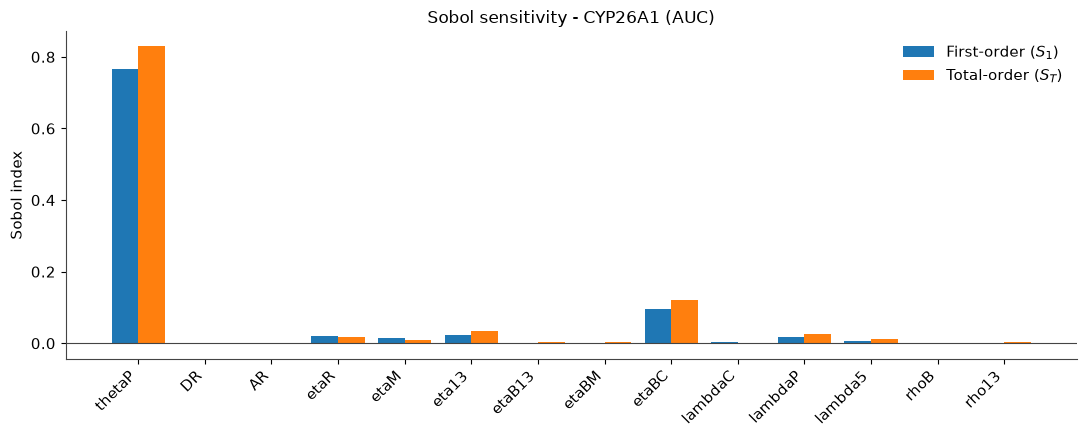

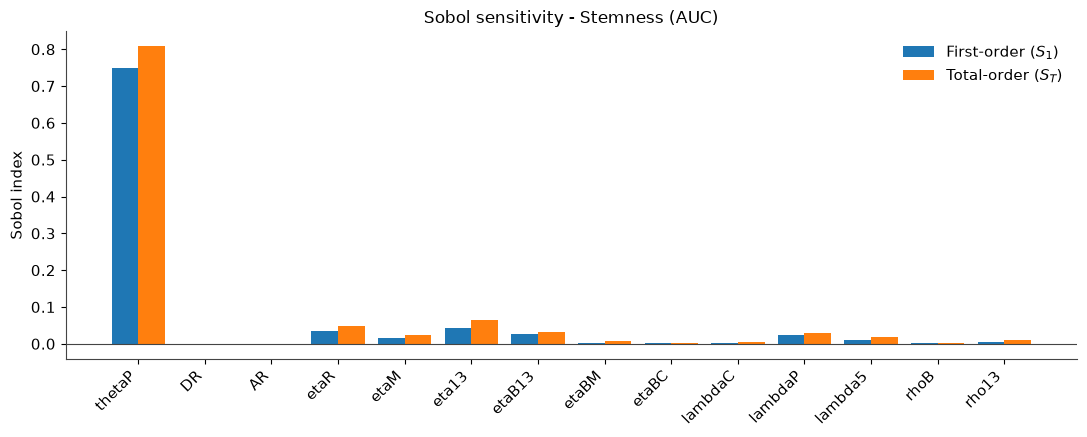

saved Sobol plots -> sa_plots


In [5]:
N_SOBOL = 256          # power of 2; total solves = N_SOBOL * (num_vars + 2). Bump to 512/1024 for smoother CIs.
X_s = sobol_sample.sample(problem, N_SOBOL, calc_second_order=False, seed=42)
print(f"Sobol: {X_s.shape[0]} solves...")
Y_s = evaluate_matrix(X_s)

x = np.arange(len(PARAMS))
w = 0.4
for o, name in enumerate(OUTPUT_NAMES):
    Si = sobol_analyze.analyze(problem, Y_s[:, o], calc_second_order=False,
                               seed=42, print_to_console=False)
    S1, ST = Si["S1"], Si["ST"]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x - w / 2, S1, w, color=BLUE,   label="First-order ($S_1$)")
    ax.bar(x + w / 2, ST, w, color=ORANGE, label="Total-order ($S_T$)")
    ax.axhline(0, color="#444444", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(PARAMS, rotation=45, ha="right")
    ax.set_ylabel("Sobol index")
    ax.set_title(f"Sobol sensitivity - {name} (AUC)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"{PLOT_DIR}/sobol_{slug(name)}.png", dpi=150)
    plt.show()
    plt.close(fig)
print("saved Sobol plots ->", PLOT_DIR)